# 03 – Feature Engineering
**AlchemiX – Launch26 Phase 2**

## What this notebook does
1. Load the **train** and **test** splits from Notebook 02
2. Apply row-wise features to both (no cross-split statistics yet)
3. Compute **historical per-link statistics from training rows only**
4. Map those stats to both train and test splits (no leakage)
5. Derive the `trust_score` regression target from telemetry
6. Save 6 engineered files: `*_train_eng.csv` and `*_test_eng.csv`

## Anti-Leakage Rules Enforced Here
| Rule | How enforced |
|---|---|
| Historical stats computed from train only | `groupby` only on `train_df`, then `.merge()` to test |
| No global-dataset means | `relative_traffic` removed (required full-dataset mean) |
| Encoder/Scaler not fitted here | That happens in Notebook 04 |
| Target column is derived, not from future data | `trust_score` = row-wise formula only |

In [ ]:
import sys, pathlib
PROJECT_ROOT = pathlib.Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ml.utils import (
    RANDOM_SEED,
    TRAFFIC_TRAIN_CLEAN, TRAFFIC_TEST_CLEAN,
    TELEMETRY_TRAIN_CLEAN, TELEMETRY_TEST_CLEAN,
    INCIDENT_TRAIN_CLEAN, INCIDENT_TEST_CLEAN,
    TRAFFIC_TRAIN_ENG, TRAFFIC_TEST_ENG,
    TELEMETRY_TRAIN_ENG, TELEMETRY_TEST_ENG,
    INCIDENT_TRAIN_ENG, INCIDENT_TEST_ENG,
    TRAFFIC_ENG_FILE, TELEMETRY_ENG_FILE, INCIDENT_ENG_FILE,
)
from ml.feature_engineering import (
    engineer_traffic_features,
    engineer_telemetry_features,
    engineer_incident_features,
)

np.random.seed(RANDOM_SEED)
print('Imports OK ✓')

Imports OK ✓


---
## Step 1 — Load Pre-Split Clean Data

In [2]:
traffic_train   = pd.read_csv(TRAFFIC_TRAIN_CLEAN)
traffic_test    = pd.read_csv(TRAFFIC_TEST_CLEAN)
telemetry_train = pd.read_csv(TELEMETRY_TRAIN_CLEAN)
telemetry_test  = pd.read_csv(TELEMETRY_TEST_CLEAN)
incident_train  = pd.read_csv(INCIDENT_TRAIN_CLEAN)
incident_test   = pd.read_csv(INCIDENT_TEST_CLEAN)

print('Split sizes loaded from Notebook 02:')
for name, tr, te in [
    ('Traffic',   traffic_train,   traffic_test),
    ('Telemetry', telemetry_train, telemetry_test),
    ('Incident',  incident_train,  incident_test),
]:
    print(f'  {name:10s}  train={len(tr)}  test={len(te)}')

Split sizes loaded from Notebook 02:
  Traffic     train=4594  test=1149
  Telemetry   train=4800  test=1200
  Incident    train=4800  test=1200


---
## ① Traffic — Row-wise Features + Historical Stats

**Row-wise features (safe on both splits):** `planet_a`, `planet_b`, `near_capacity`, `load_bucket`, `load_ratio_sq`, `load_units_x_ratio`

**Historical features (from train only):** `hist_mean_load_ratio`, `hist_std_load_ratio`, `hist_mean_load_units`

In [3]:
# Row-wise features — applied independently to each split
traf_train_fe = engineer_traffic_features(traffic_train)
traf_test_fe  = engineer_traffic_features(traffic_test)
print(f'Row-wise features applied. Columns: {list(traf_train_fe.columns)}')

14:57:59  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
14:57:59  INFO      ml.feature_engineering  engineer_traffic_features: 12 features, 4594 rows
14:57:59  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
14:57:59  INFO      ml.feature_engineering  engineer_traffic_features: 12 features, 1149 rows


Row-wise features applied. Columns: ['link_id', 'tick', 'load_units', 'load_ratio', 'status', 'observed_latency_ms', 'planet_a', 'planet_b', 'near_capacity', 'load_bucket', 'load_ratio_sq', 'load_units_x_ratio']


In [4]:
# Historical stats — computed from TRAIN only, then joined to BOTH splits
hist_traffic = (
    traf_train_fe
    .groupby('link_id')[['load_ratio', 'load_units']]
    .agg(
        hist_mean_load_ratio=('load_ratio', 'mean'),
        hist_std_load_ratio=('load_ratio', 'std'),
        hist_mean_load_units=('load_units', 'mean'),
    )
    .reset_index()
)
print('Per-link historical stats (from train only):')
display(hist_traffic.round(4))

# Map to train and test (test gets train-computed stats only)
global_fallback = {
    'hist_mean_load_ratio':  traf_train_fe['load_ratio'].mean(),
    'hist_std_load_ratio':   traf_train_fe['load_ratio'].std(),
    'hist_mean_load_units':  traf_train_fe['load_units'].mean(),
}
traf_train_fe = traf_train_fe.merge(hist_traffic, on='link_id', how='left').fillna(global_fallback)
traf_test_fe  = traf_test_fe.merge(hist_traffic,  on='link_id', how='left').fillna(global_fallback)

print(f'\nAfter historical join  —  train: {traf_train_fe.shape}  test: {traf_test_fe.shape}')
print('All hist_ columns:', [c for c in traf_train_fe.columns if 'hist_' in c])

Per-link historical stats (from train only):


,link_id,hist_mean_load_ratio,hist_std_load_ratio,hist_mean_load_units
0,Aegis-Boreas,0.2912,0.1678,59.9753
1,Aegis-Dawn,0.3143,0.1656,31.2589
2,Aegis-Elysium,0.3029,0.1668,60.3628
3,Boreas-Dawn,0.2930,0.1673,58.5201
4,Boreas-Elysium,0.2901,0.1651,59.0683
5,Boreas-Fenix,0.3081,0.1701,51.7546
6,Caelum-Dawn,0.3043,0.1737,28.5269
7,Caelum-Elysium,0.2990,0.1647,25.3445
8,Caelum-Fenix,0.2980,0.1691,38.0410
9,Dawn-Elysium,0.2960,0.1691,20.8723



After historical join  —  train: (4594, 15)  test: (1149, 15)
All hist_ columns: ['hist_mean_load_ratio', 'hist_std_load_ratio', 'hist_mean_load_units']


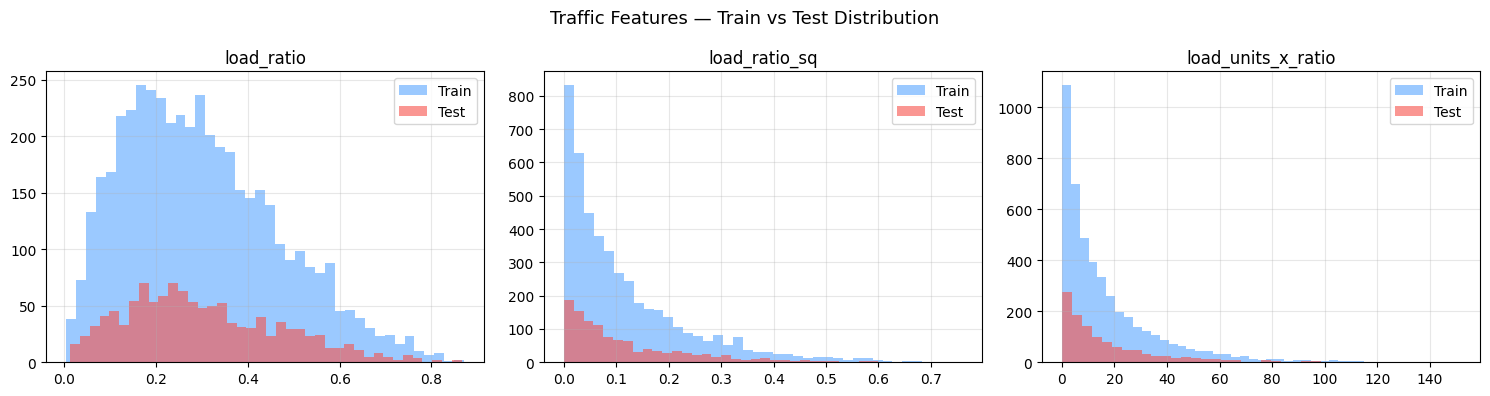

In [5]:
# Visualise: load_ratio distribution in train vs test
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ['load_ratio', 'load_ratio_sq', 'load_units_x_ratio']):
    ax.hist(traf_train_fe[col], bins=40, alpha=0.6, color='#58a6ff', label='Train')
    ax.hist(traf_test_fe[col],  bins=40, alpha=0.6, color='#f85149', label='Test')
    ax.set_title(col)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Traffic Features — Train vs Test Distribution', fontsize=13)
plt.tight_layout()
plt.show()

---
## ② Telemetry — Row-wise Features + trust_score Target + Historical Stats

**Trust score formula (row-wise, no cross-row info):**
```
diff  = measured_latency_ms − self_reported_latency_ms
trust = 1 / (1 + max(0, diff) / measured_latency_ms)
```
- If self_reported ≥ measured (honest): diff ≤ 0  →  trust = 1.0
- If self_reported < measured (dishonest): trust ∈ (0.5, 1.0)

In [6]:
tele_train_fe = engineer_telemetry_features(telemetry_train)
tele_test_fe  = engineer_telemetry_features(telemetry_test)

print('trust_score — Train:')
print(tele_train_fe['trust_score'].describe().round(4).to_string())
print('\ntrust_score — Test:')
print(tele_test_fe['trust_score'].describe().round(4).to_string())

14:57:59  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
14:57:59  INFO      ml.feature_engineering  engineer_telemetry_features: 11 features, 4800 rows
14:57:59  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
14:57:59  INFO      ml.feature_engineering  engineer_telemetry_features: 11 features, 1200 rows


trust_score — Train:
count    4800.0000
mean        0.9511
std         0.0974
min         0.5315
25%         0.9639
50%         0.9939
75%         1.0000
max         1.0000

trust_score — Test:
count    1200.0000
mean        0.9485
std         0.0999
min         0.5857
25%         0.9643
50%         0.9925
75%         1.0000
max         1.0000


In [7]:
# Historical telemetry stats — from train only
hist_tele = (
    tele_train_fe
    .groupby('link_id')[['trust_score', 'latency_difference']]
    .agg(
        hist_mean_trust=('trust_score', 'mean'),
        hist_std_trust=('trust_score', 'std'),
        hist_mean_latency_diff=('latency_difference', 'mean'),
    )
    .reset_index()
)
print('Per-link trust history (from train only):')
display(hist_tele.round(4))

global_tele_fallback = {
    'hist_mean_trust':        tele_train_fe['trust_score'].mean(),
    'hist_std_trust':         tele_train_fe['trust_score'].std(),
    'hist_mean_latency_diff': tele_train_fe['latency_difference'].mean(),
}
tele_train_fe = tele_train_fe.merge(hist_tele, on='link_id', how='left').fillna(global_tele_fallback)
tele_test_fe  = tele_test_fe.merge(hist_tele,  on='link_id', how='left').fillna(global_tele_fallback)

print(f'\nAfter historical join  —  train: {tele_train_fe.shape}  test: {tele_test_fe.shape}')

Per-link trust history (from train only):


,link_id,hist_mean_trust,hist_std_trust,hist_mean_latency_diff
0,Aegis-Boreas,0.9850,0.0341,-4121.5681
1,Aegis-Dawn,0.9844,0.0368,-2180.4743
2,Aegis-Elysium,0.7959,0.1315,77214.9570
3,Boreas-Dawn,0.9792,0.0529,-992.1217
4,Boreas-Elysium,0.9805,0.0553,-1839.5135
5,Boreas-Fenix,0.8068,0.1351,61601.1082
6,Caelum-Dawn,0.9805,0.0545,-6484.0574
7,Caelum-Elysium,0.9780,0.0600,1753.5802
8,Caelum-Fenix,0.9797,0.0487,1731.9079
9,Dawn-Elysium,0.9839,0.0403,-3087.7173



After historical join  —  train: (4800, 14)  test: (1200, 14)


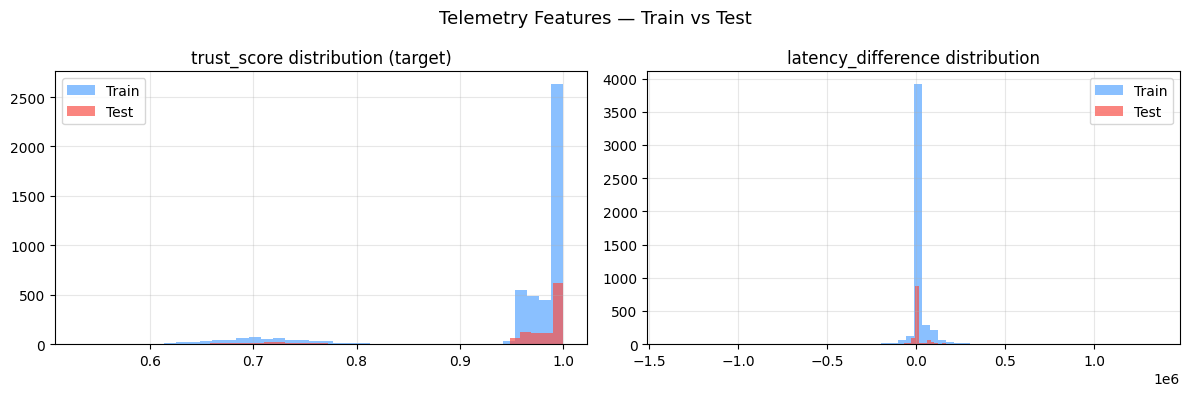

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(tele_train_fe['trust_score'], bins=40, color='#58a6ff', alpha=0.7, label='Train')
axes[0].hist(tele_test_fe['trust_score'],  bins=40, color='#f85149', alpha=0.7, label='Test')
axes[0].set_title('trust_score distribution (target)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].hist(tele_train_fe['latency_difference'], bins=60, color='#58a6ff', alpha=0.7, label='Train')
axes[1].hist(tele_test_fe['latency_difference'],  bins=60, color='#f85149', alpha=0.7, label='Test')
axes[1].set_title('latency_difference distribution')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.suptitle('Telemetry Features — Train vs Test', fontsize=13)
plt.tight_layout()
plt.show()

---
## ③ Incident — Row-wise Features + Historical Attack Rate

**Historical feature (from train only):** `hist_attack_rate` = per-link jam rate in training rows

In [9]:
inc_train_fe = engineer_incident_features(incident_train)
inc_test_fe  = engineer_incident_features(incident_test)

print('Incident jam rate — Train:', inc_train_fe['jammed_flag'].mean().round(4))
print('Incident jam rate — Test: ', inc_test_fe['jammed_flag'].mean().round(4))

14:58:00  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
14:58:00  INFO      ml.feature_engineering  engineer_incident_features: 10 features, 4800 rows
14:58:00  INFO      ml.feature_engineering  split_link_id: added planet_a, planet_b columns
14:58:00  INFO      ml.feature_engineering  engineer_incident_features: 10 features, 1200 rows


Incident jam rate — Train: 0.0821
Incident jam rate — Test:  0.0825


In [10]:
# Historical attack rate — from train only
inc_train_fe['jammed_flag'] = inc_train_fe['jammed_flag'].astype(int)
inc_test_fe['jammed_flag']  = inc_test_fe['jammed_flag'].astype(int)

hist_inc = (
    inc_train_fe
    .groupby('link_id')['jammed_flag']
    .agg(hist_attack_rate='mean')
    .reset_index()
)
print('Per-link historical attack rate (from train only):')
display(hist_inc.round(4))

global_inc_fallback = {'hist_attack_rate': inc_train_fe['jammed_flag'].mean()}
inc_train_fe = inc_train_fe.merge(hist_inc, on='link_id', how='left').fillna(global_inc_fallback)
inc_test_fe  = inc_test_fe.merge(hist_inc,  on='link_id', how='left').fillna(global_inc_fallback)

print(f'\nAfter historical join  —  train: {inc_train_fe.shape}  test: {inc_test_fe.shape}')

Per-link historical attack rate (from train only):


,link_id,hist_attack_rate
0,Aegis-Boreas,0.1150
1,Aegis-Dawn,0.0861
2,Aegis-Elysium,0.0680
3,Boreas-Dawn,0.0762
4,Boreas-Elysium,0.0893
5,Boreas-Fenix,0.1035
6,Caelum-Dawn,0.0667
7,Caelum-Elysium,0.0821
8,Caelum-Fenix,0.0796
9,Dawn-Elysium,0.0764



After historical join  —  train: (4800, 11)  test: (1200, 11)


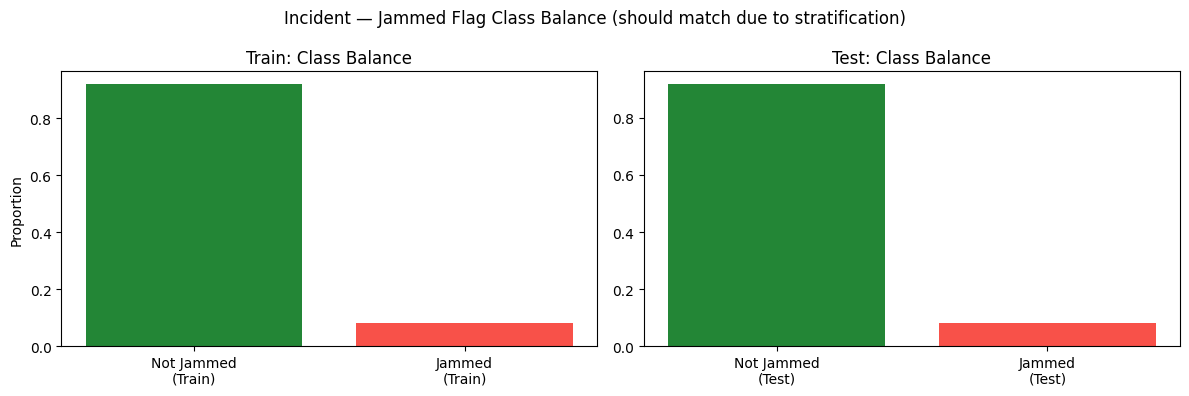

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Not Jammed\n(Train)', 'Jammed\n(Train)'],
    [(1 - inc_train_fe['jammed_flag'].mean()), inc_train_fe['jammed_flag'].mean()],
    color=['#238636', '#f85149'])
axes[0].set_title('Train: Class Balance')
axes[0].set_ylabel('Proportion')

axes[1].bar(['Not Jammed\n(Test)', 'Jammed\n(Test)'],
    [(1 - inc_test_fe['jammed_flag'].mean()), inc_test_fe['jammed_flag'].mean()],
    color=['#238636', '#f85149'])
axes[1].set_title('Test: Class Balance')

plt.suptitle('Incident — Jammed Flag Class Balance (should match due to stratification)', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 6 — Save Engineered Train/Test Files

In [12]:
# Train engineered
traf_train_fe.to_csv(TRAFFIC_TRAIN_ENG,   index=False)
tele_train_fe.to_csv(TELEMETRY_TRAIN_ENG, index=False)
inc_train_fe.to_csv(INCIDENT_TRAIN_ENG,   index=False)

# Test engineered
traf_test_fe.to_csv(TRAFFIC_TEST_ENG,    index=False)
tele_test_fe.to_csv(TELEMETRY_TEST_ENG,  index=False)
inc_test_fe.to_csv(INCIDENT_TEST_ENG,    index=False)

# Also save full engineered (train+test concatenated) for EDA
import pandas as pd
pd.concat([traf_train_fe, traf_test_fe], ignore_index=True).to_csv(TRAFFIC_ENG_FILE,   index=False)
pd.concat([tele_train_fe, tele_test_fe], ignore_index=True).to_csv(TELEMETRY_ENG_FILE, index=False)
pd.concat([inc_train_fe,  inc_test_fe],  ignore_index=True).to_csv(INCIDENT_ENG_FILE,  index=False)

print('Saved engineered files:')
import pathlib
for label, f in [
    ('Traffic   TRAIN', TRAFFIC_TRAIN_ENG),   ('Traffic   TEST', TRAFFIC_TEST_ENG),
    ('Telemetry TRAIN', TELEMETRY_TRAIN_ENG), ('Telemetry TEST', TELEMETRY_TEST_ENG),
    ('Incident  TRAIN', INCIDENT_TRAIN_ENG),  ('Incident  TEST', INCIDENT_TEST_ENG),
]:
    rows = len(pd.read_csv(f))
    print(f'  {label:<20}  {pathlib.Path(f).name:<35}  {rows:5d} rows')

print('\n✓ Notebook 03 complete — proceed to Notebook 04 Model Training.')

Saved engineered files:
  Traffic   TRAIN       traffic_train_eng.csv                 4594 rows
  Traffic   TEST        traffic_test_eng.csv                  1149 rows
  Telemetry TRAIN       telemetry_train_eng.csv               4800 rows
  Telemetry TEST        telemetry_test_eng.csv                1200 rows
  Incident  TRAIN       incident_train_eng.csv                4800 rows
  Incident  TEST        incident_test_eng.csv                 1200 rows

✓ Notebook 03 complete — proceed to Notebook 04 Model Training.
